<a href="https://colab.research.google.com/github/parasG0/backpropExample-/blob/main/Backprop_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [85]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [86]:
class value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data=data
    self.grad=0.0
    self._prev=set(_children)
    self._op=_op
    self.label=label
    self._backward = lambda: None

  def __repr__(self):
    return f"value(data={self.data})"

  def __add__(self,other):
    out=value(self.data+other.data, (self,other),'+')
    def _backward():
      self.grad+=1.0*out.grad
      other.grad+=1.0*out.grad
    out._backward =_backward

    return out



  def __mul__(self, other):
    out=value( self.data *other.data, (self,other), '*')
    def _backward():
      self.grad+=other.data * out.grad
      other.grad+=self.data*out.grad
    out._backward =_backward
    return out


  def __sub__(self,other):
    out=value(self.data-other.data, (self,other), '-')
    return out

  def tanh(self):
    x=self.data
    t= (math.exp(x*2)-1) /( math.exp(x*2)+1)
    out=value(t,(self , ), 'tanh' )

    def _backward():
      self.grad+=(1-t**2)*out.grad

    out._backward =_backward
    return out

  def backward(self):
    topo =[]
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad=1.0
    for node in reversed(topo):
      node._backward()
  # def __div__(self,other):
  #   out=self.data/other.data
  #   return out



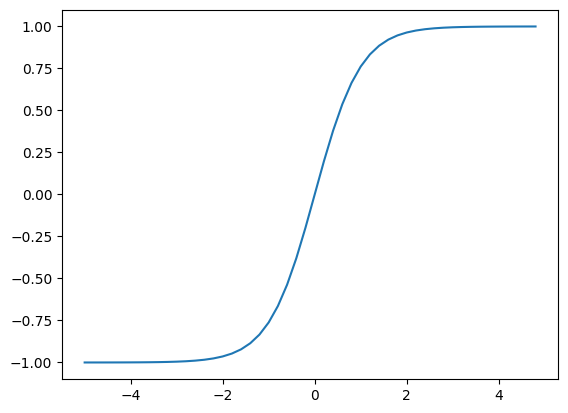

In [87]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();
plt.grid();

In [88]:
import graphviz
from graphviz import Digraph


def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [89]:
#inputs x1 and x2
x1=value(2.0, label='x1')
x2=value(1.0, label='x2')
#weights w1 and w2
w1=value(-3.0, label='w1')
w2=value(0.5, label='w2')
#bias
b=value(6.0, label='bias')
x1w1=x1*w1; x1w1.label='x1w1'
x2w2=x2*w2; x2w2.label='x2w2'
x1w1x2w2= x1w1 + x2w2; x1w1x2w2.label='x1w1+x2w2'
n=x1w1x2w2+b; n.label='n'
o=n.tanh(); o.label='o'

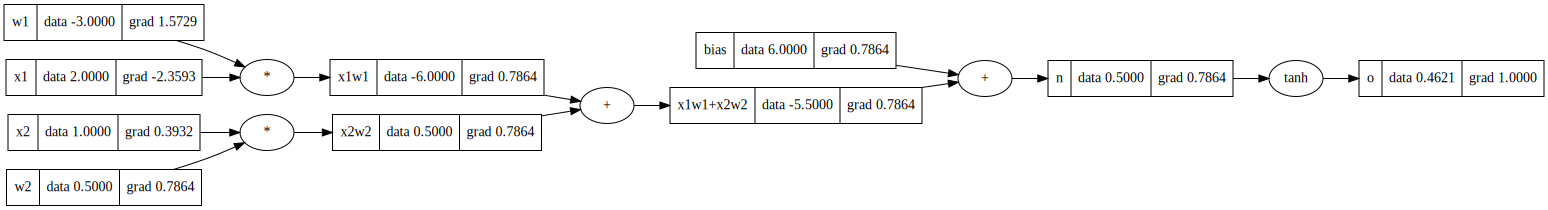

In [98]:
draw_dot(o)

In [97]:
o.backward()

In [91]:
# o._backward()
# n._backward()
# x1w1x2w2._backward()
# x1w1._backward()
# x2w2._backward()
# x1._backward()
# x2._backward()
# w1._backward()
# w2._backward()

In [92]:
#manual giving the valuw of the gradients
# o.grad=1.0
# n.grad=1-o.data**2
# b.grad=n.grad
# x1w1x2w2.grad=n.grad
# x1w1.grad=n.grad
# x2w2.grad=n.grad
# x1.grad=n.grad*w1.data
# w1.grad=n.grad*x1.data

# x2.grad=n.grad*w2.data
# w2.grad=n.grad*x2.data


let's solve some see and some some bug we had

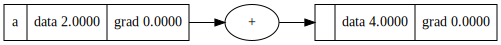

In [110]:
a=value(2.0, label='a')
c=value(3.0, label='c')
m=a+a; b.label='b'

b.backward()
draw_dot(m)

that's corrected after accumulating the gradients

In [111]:
b=a+c; b.label='b'
d=a*c; d.label='d'
e=b+d; e.label='e'
e.backward()


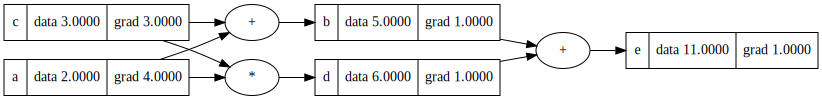

In [112]:
draw_dot(e)